# Лабораторная работа
Анализ и прогнозирование временного ряда
**Выполнил:** Хрипков Тимофей, группа ИУ5-65Б

## Цель лабораторной работы
Изучение основных методов анализа и прогнозирования временных рядов.

## Описание задания
1. Выбрать набор данных для прогнозирования временного ряда.
2. Визуализировать ряд и его характеристики.
3. Разделить данные на обучающую и тестовую выборки.
4. Произвести прогнозирование методами ARIMA, символьной регрессии и альтернативными методами.
5. Визуализировать результаты и оценить метрики качества.

In [ ]:
# Установка gplearn (только для Google Colab)
!pip install gplearn -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from gplearn.genetic import SymbolicRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


# Выбор набора данных

Для анализа выбран ряд **Air Passengers** — количество пассажиров авиакомпаний по месяцам с 1949 по 1960 год. Данный набор данных является классическим для демонстрации методов прогнозирования временных рядов, имеет ярко выраженную сезонность и тренд.

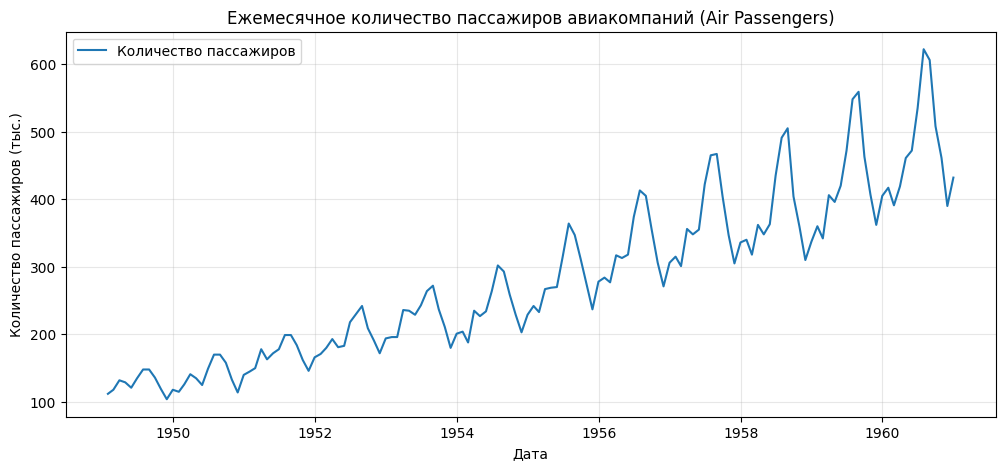

In [ ]:
# Загрузка данных Air Passengers
data = sm.datasets.get_rdataset("AirPassengers").data
ts = data['value']
ts.index = pd.date_range(start='1949-01-01', periods=len(ts), freq='M')

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(ts, label='Количество пассажиров')
plt.title('Ежемесячное количество пассажиров авиакомпаний (Air Passengers)')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров (тыс.)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Основные характеристики ряда

Построим графики автокорреляции (ACF) и частичной автокорреляции (PACF). Это позволит оценить стационарность и выбрать лаги для моделей.

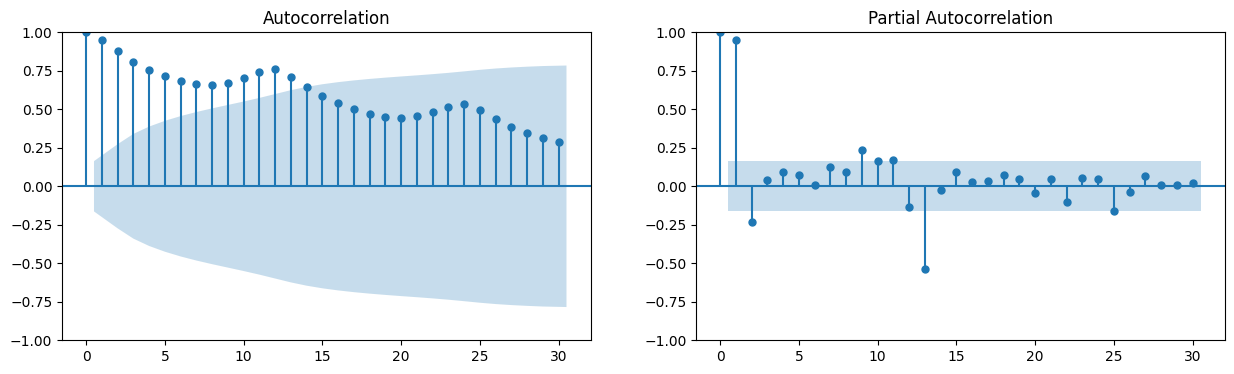

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(ts, ax=axes[0], lags=30)
plot_pacf(ts, ax=axes[1], lags=30)
plt.show()

# Разделение выборки

Разделим ряд на обучающую и тестовую части. Тестовая выборка составит последние 24 месяца (2 года).

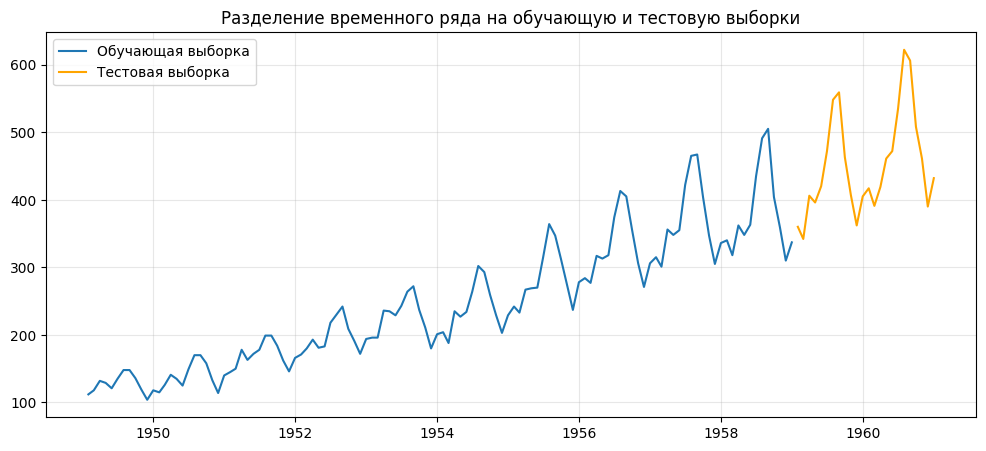

In [ ]:
test_size = 24
train_ts = ts[:-test_size]
test_ts = ts[-test_size:]

plt.figure(figsize=(12, 5))
plt.plot(train_ts, label='Обучающая выборка')
plt.plot(test_ts, label='Тестовая выборка', color='orange')
plt.title('Разделение временного ряда на обучающую и тестовую выборки')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Прогнозирование методом ARIMA

Используем модель ARIMA(2,1,2) с сезонной компонентой, так как ряд имеет ярко выраженный тренд и сезонность.

In [ ]:
# Обучение и прогноз
model_arima = ARIMA(train_ts, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12))
res_arima = model_arima.fit()
pred_arima = res_arima.forecast(steps=test_size)
pred_arima.index = test_ts.index

print(res_arima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  120
Model:             ARIMA(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -396.700
Date:                            Wed, 03 Jun 2026   AIC                            807.401
Time:                                    23:15:14   BIC                            826.110
Sample:                                01-31-1949   HQIC                           814.985
                                     - 12-31-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3111      0.415      0.749      0.454      -0.503       1.125
ar.L2          0.4826      0.359   

# Подготовка признаков для машинного обучения

Для регрессионных моделей создадим признаки на основе лагов ряда (значения за предыдущие 12 месяцев — для учёта годовой сезонности).

In [ ]:
def create_features(series, lags=12):
    df = series.to_frame()
    df.columns = ['target']
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df['target'].shift(i)
    return df.dropna()

# Формирование датасета
df_ml = create_features(ts, lags=12)

# Разделение по дате, соответствующей началу тестовой выборки
X = df_ml.drop('target', axis=1)
y = df_ml['target']

X_train = X[X.index < test_ts.index[0]]
y_train = y[y.index < test_ts.index[0]]
X_test = X[X.index >= test_ts.index[0]]
y_test = y[y.index >= test_ts.index[0]]

# Символьная регрессия

Модель генетического программирования для поиска аналитической зависимости.

In [ ]:
model_sr = SymbolicRegressor(
    population_size=1000,
    generations=20,
    random_state=42,
    verbose=0
)
model_sr.fit(X_train, y_train)
pred_sr = model_sr.predict(X_test)
pred_sr = pd.Series(pred_sr, index=y_test.index)

# Линейный и нелинейный методы

Используем Линейную регрессию и Случайный лес.

In [ ]:
# Линейная регрессия
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
pred_lr = pd.Series(pred_lr, index=y_test.index)

# Случайный лес
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
pred_rf = pd.Series(pred_rf, index=y_test.index)

# Визуализация результатов и оценка качества

Сравним все полученные прогнозы с реальными данными.

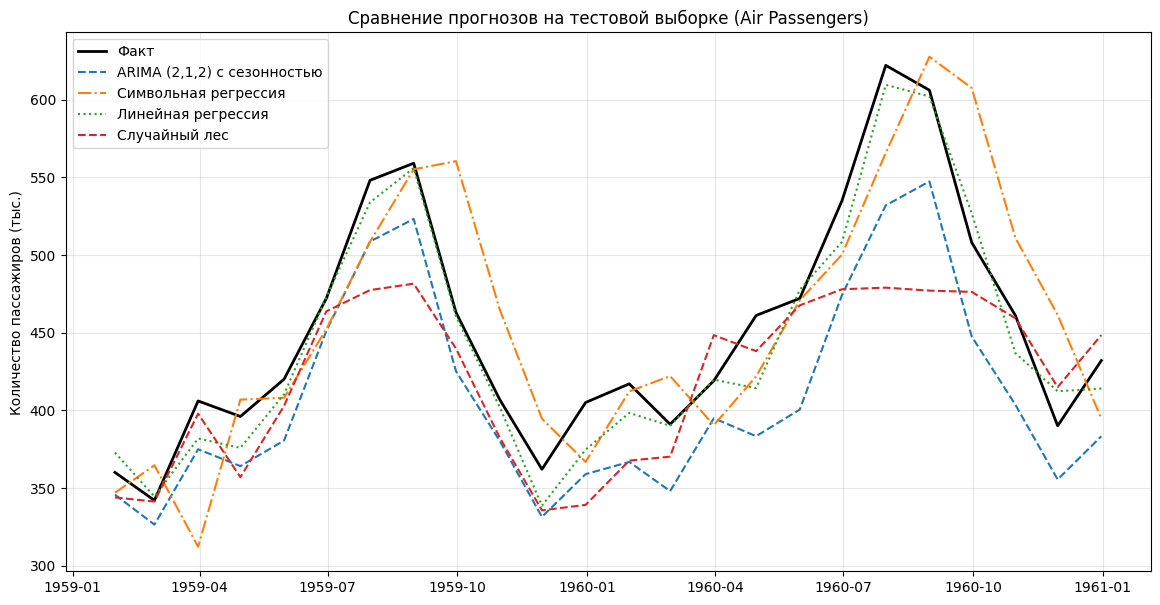


Метрики точности прогнозирования:
--------------------------------------------------
ARIMA: MAE=43.64, RMSE=47.60, MAPE=0.0946
Символьная регрессия: MAE=38.24, RMSE=47.51, MAPE=0.0858
Линейная регрессия: MAE=14.49, RMSE=18.45, MAPE=0.0331
Случайный лес: MAE=37.87, RMSE=52.42, MAPE=0.0774


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_ts.index, test_ts.values, label='Факт', color='black', linewidth=2)
plt.plot(test_ts.index, pred_arima.values, label='ARIMA (2,1,2) с сезонностью', linestyle='--')
plt.plot(y_test.index, pred_sr, label='Символьная регрессия', linestyle='-.')
plt.plot(y_test.index, pred_lr, label='Линейная регрессия', linestyle=':')
plt.plot(y_test.index, pred_rf, label='Случайный лес', linestyle='--')

plt.title('Сравнение прогнозов на тестовой выборке (Air Passengers)')
plt.ylabel('Количество пассажиров (тыс.)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def get_metrics(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = mean_absolute_percentage_error(true, pred)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.4f}")

print("\nМетрики точности прогнозирования:")
print("-" * 50)
get_metrics(test_ts, pred_arima, "ARIMA")
get_metrics(y_test, pred_sr, "Символьная регрессия")
get_metrics(y_test, pred_lr, "Линейная регрессия")
get_metrics(y_test, pred_rf, "Случайный лес")